In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('/content/train.csv')

In [2]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

In [4]:
df['SalePrice'].head()

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


In [5]:
y = df['SalePrice']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Target Distribution

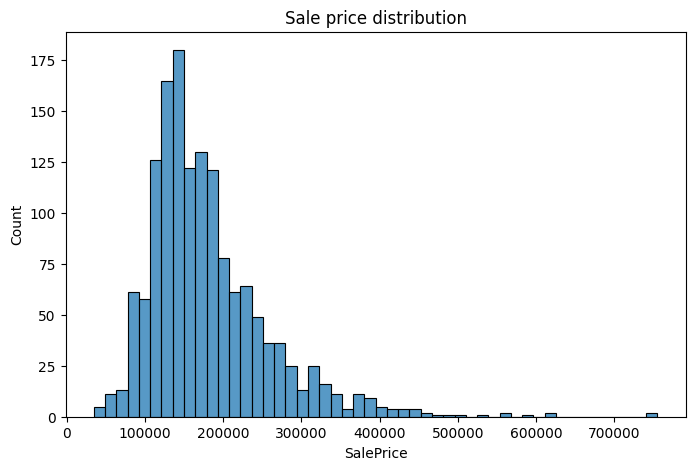

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins = 50)
plt.title("Sale price distribution")
plt.show()

graph is right skewed

most of the hoses lie in the range of 100k-250k

and very few houses are expensive i.e above 500k


In [9]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(
    ascending=False
).head(20)
missing

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


Correlation Analysis ---> which feature influencing the prices most

In [11]:
corr = df.corr(
    numeric_only=True
)
corr['SalePrice'].sort_values(
    ascending=False
).head(20)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


Correlation Visualization

In [12]:
top_features = corr['SalePrice'].sort_values(ascending=False).head(10)
print(top_features)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


Scatter plot

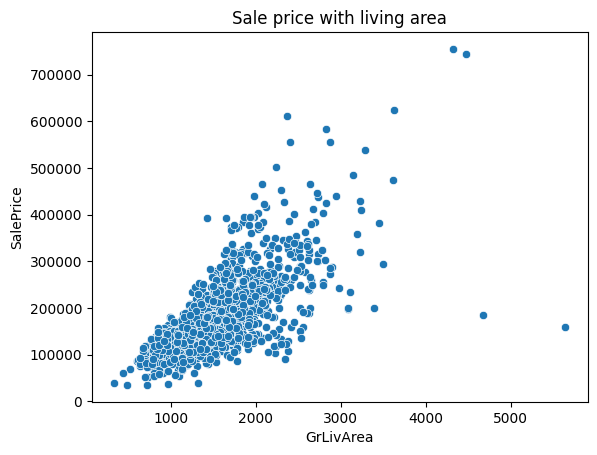

In [13]:
sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=df
)
plt.title('Sale price with living area')
plt.show()

Overall quality vs Price

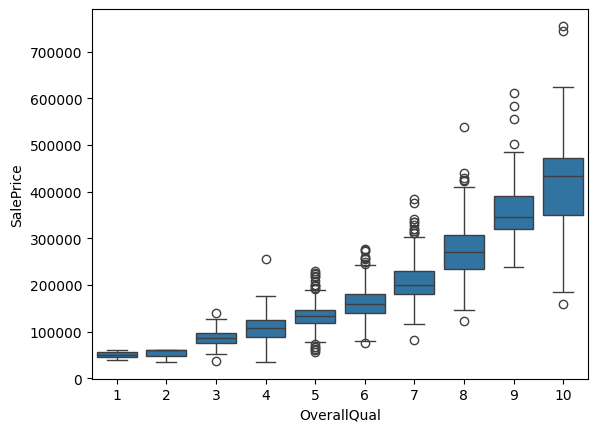

In [14]:
sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df
)
plt.show()

High quality houses sell more and at higher prices

Data Cleaning and pre processing

In [15]:
y = df['SalePrice']

In [16]:
x = df.drop('SalePrice',axis=1)

Identifying numerical and catagorical columns

In [17]:
num_cols = x.select_dtypes(include = np.number).columns
cat_cols = x.select_dtypes(exclude = np.number).columns

In [18]:
print('Numerical cols : ',num_cols,'  length : ', len(num_cols))
print('\nCatagorical cols : ',cat_cols,'   length : ', len(cat_cols))

Numerical cols :  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')   length :  37

Catagorical cols :  Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinTy

In [19]:
x.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


Handling Missing values

median is resistant to outliers so it's a common practice to use median in place of missing values

In [20]:
for col in num_cols:
  x[col] = x[col].fillna(x[col].median())

filling catogorical values with mode

In [21]:
for cat in cat_cols:
  x[cat] = x[cat].fillna(x[cat].mode()[0])

In [22]:
x.isnull().sum().sum()

np.int64(0)

model's cannot understand the categorical variables so converting them to numbers

One Hot Encoder

In [23]:
x = pd.get_dummies(
    x,
    drop_first=True
)

In [24]:
x.shape

(1460, 245)

In [25]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
print(x_train.shape)
print(x_test.shape)

(1168, 245)
(292, 245)


Feature Scaling --linear regression doesn't strictly require standard scaling as logistic regression but it's a good practice to do

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [29]:
lr.fit(x_train_scaled,y_train)

LinearRegression()

In [30]:
predictions = lr.predict(x_test_scaled)

In [31]:
print(predictions[:5])

[157784.9489938  349289.1805791   86449.6650514  174007.5574392
 317396.24983957]


Evaluate Model

In [32]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error)
mae = mean_absolute_error(predictions,y_test)
print(mae)

20232.175887938276


In [33]:
mse = mean_squared_error(predictions, y_test)
print(mse)

2642483715.1951137


In [34]:
rmse = np.sqrt(mse)
print(rmse)

51405.09425334335


R square score

In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(predictions,y_test)
print(r2)

0.6724852532274259


Actual vs predicted plot

Text(0, 0.5, 'Predicted Prices')

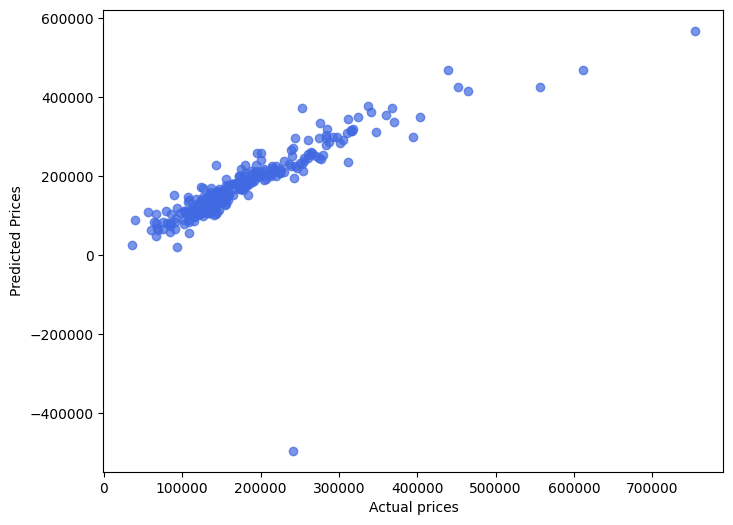

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    predictions,
    c='royalblue',
    alpha=0.7
)
plt.xlabel('Actual prices')
plt.ylabel('Predicted Prices')

Feature Engineering to improve performance

outliers in sale price



visualizing the sale price

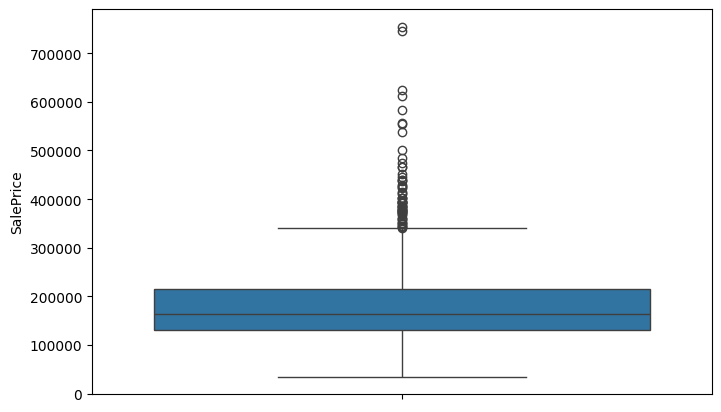

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(y)
plt.show()

we can see there are lot of outliers in the data i.e several expensive houses are far from main group

Removing extreme outliers

In [38]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df_no_outliers = df[
    (df['SalePrice']>=lower) & (df['SalePrice']<=upper)
]

In [39]:
print(df.shape)
print(df_no_outliers.shape)

(1460, 81)
(1399, 81)


Feature Selection -----> not every feature help's some add noise like keeping noisy features may confuse the model during training

In [40]:
corr = df.corr(numeric_only=True)
top_corr = corr['SalePrice'].abs().sort_values(ascending=False)
print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


Random Regression ---> assumes nonlinear patterns suitable for complex relaations here houses prices are more complexly related so
linear regrssion ----> assumes linear patterns

In [41]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

fitting data

scaling is not required to randomforest

In [42]:
rf.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [43]:
rf_pred = rf.predict(x_test)

Evaluate

In [44]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [45]:
mae = mean_absolute_error(y_test,rf_pred)
mse = mean_squared_error(y_test,rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,rf_pred)
print('Mean Absolute Error : ',mae)
print('Root Mean Squared Error : ',rmse)
print('r2_score : ',r2)

Mean Absolute Error :  17481.776643835616
Root Mean Squared Error :  28352.112565630196
r2_score :  0.8952010298882774


Feature Importance ----> one of the biggest benifit of the randomforestregression is that which feature contributed more after training data in decision making

In [46]:
importance = pd.DataFrame({
    'Feature':x.columns,
    'Importance':rf.feature_importances_
})
importance = importance.sort_values(
    by = "Importance",
    ascending = False
)
print(importance.head(15))
print(top_corr.head(15))

              Feature  Importance
4         OverallQual    0.557449
16          GrLivArea    0.120819
12        TotalBsmtSF    0.034973
14           2ndFlrSF    0.034354
9          BsmtFinSF1    0.029543
13           1stFlrSF    0.025664
3             LotArea    0.016596
27         GarageArea    0.016203
26         GarageCars    0.012389
6           YearBuilt    0.011702
2         LotFrontage    0.008939
23       TotRmsAbvGrd    0.006751
213  GarageFinish_Unf    0.006686
29        OpenPorchSF    0.006546
7        YearRemodAdd    0.006396
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


visualize

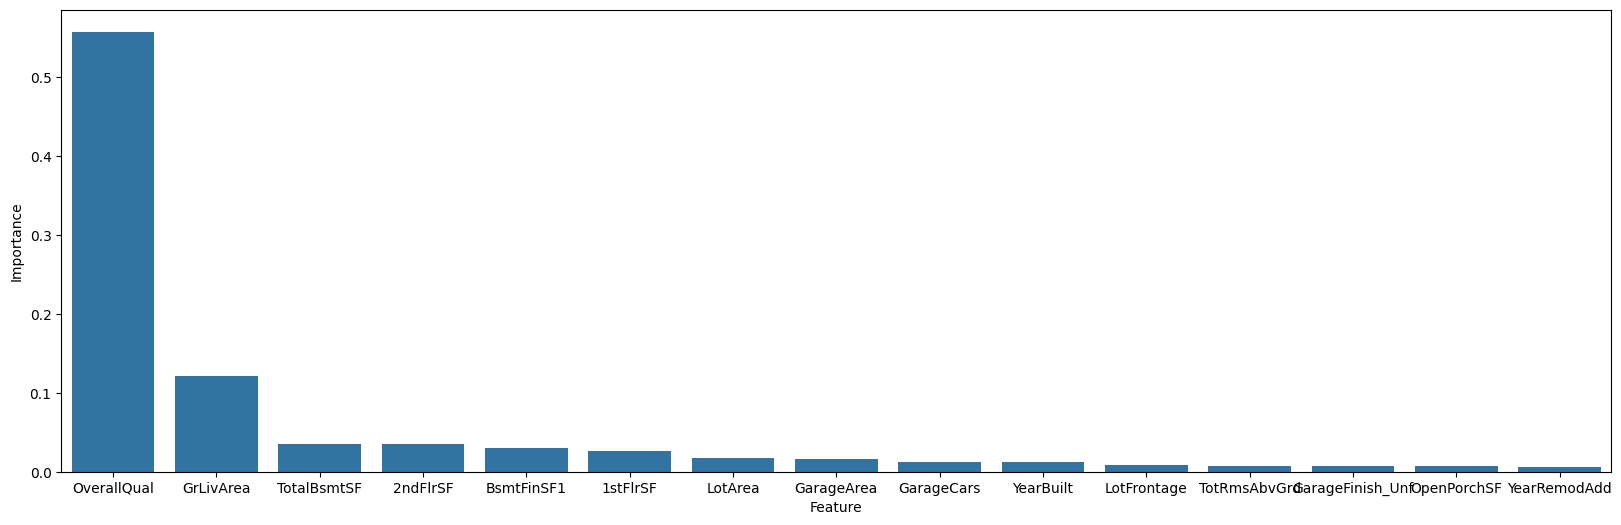

In [47]:
top15 = importance.head(15)
plt.figure(figsize=(20,6))
sns.barplot(
    top15,
    x='Feature',
    y='Importance'
)
plt.show()

cross validation

single train test split may be misleading

In [48]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf,
    x,
    y,
    cv=5,
    scoring='r2'
)
print(scores)
print(scores.mean())

[0.87095275 0.84346673 0.86825704 0.88404917 0.80982045]
0.8553092283158461


86% so it's reliable splitting is smooth nothing to worry model splitting data well

Hyperparameter Tuning

try's to improve the forest

In [49]:
rf2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

In [50]:
rf2.fit(x_train,y_train)
pred2 = rf2.predict(x_test)
print(r2_score(y_test,pred2))


0.8898214700109905


In [51]:
import joblib
joblib.dump(
    rf,
    'house_price_model.pkl'
)

['house_price_model.pkl']

In [52]:
! pip freeze > requirements.txt

Mini diployment test

In [58]:
sample = x_test.iloc[[0]]
predicted_price1 = rf2.predict(sample)
predicted_price2 = rf.predict(sample)
print(predicted_price1)
print(predicted_price2)
print (y_test.head(1))

[141134.04296416]
[141543.75]
892    154500
Name: SalePrice, dtype: int64
